# Palace Field Visualization

Top-view and cross-section visualization of electromagnetic fields from a
Palace driven simulation on a CPW (coplanar waveguide) structure at 50 GHz.

**Requirements:**

- IHP PDK: `uv pip install ihp-gdsfactory`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

---
**Note:** This notebook now uses :func:`gsim.palace.fields.plot_boundary_field`
for NaN-free direct-mesh rendering (replaces the old probe-grid resampling
approach that produced NaN values and poor-quality plots).

### Simulation setup

In [2]:
import gdsfactory as gf
from ihp import LAYER, PDK

from gsim.common.stack import get_stack
from gsim.palace import DrivenSim

PDK.activate()


@gf.cell
def gsg_electrode(
    length=300, s_width=20, g_width=40, gap_width=15, layer=LAYER.TopMetal2drawing
):
    c = gf.Component()
    r1 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r1.move((0, (g_width + s_width) / 2 + gap_width))
    _r2 = c << gf.c.rectangle((length, s_width), centered=True, layer=layer)
    r3 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r3.move((0, -(g_width + s_width) / 2 - gap_width))
    c.add_port(
        name="o1",
        center=(-length / 2, 0),
        width=s_width,
        orientation=180,
        port_type="electrical",
        layer=layer,
    )
    c.add_port(
        name="o2",
        center=(length / 2, 0),
        width=s_width,
        orientation=0,
        port_type="electrical",
        layer=layer,
    )
    return c


sim = DrivenSim()
sim.set_output_dir("./palace-sim-cpw-fields")
sim.set_geometry(gsg_electrode())

stack = get_stack(
    include_substrate=True, substrate_thickness=2.0
)  # auto-detects active PDK
sim.set_stack(stack)

sim.add_cpw_port("o1", layer="topmetal2", s_width=20, gap_width=15)
sim.add_cpw_port("o2", layer="topmetal2", s_width=20, gap_width=15)

# Single frequency point at 50 GHz, adaptive off so Palace does a full solve
sim.set_driven(
    fmin=50e9,
    fmax=50e9 + 1e6,  # tiny range = effectively one point
    num_points=1,
    adaptive_tol=0,
    save_step=1,
)
sim.set_airbox(margin_x=50, margin_y=0, z_above=100, z_below=100)
sim.mesh(
    preset="default",
    refined_mesh_size=2.0,
    max_mesh_size=25.0,
)

Mesh Summary
Dimensions: 500.0 x 130.0 x 217.9 µm
Nodes:      16,745
Elements:   124,068
Tetrahedra: 90,126
Edge length: 1.12 - 51.35 µm
Quality:    0.645 (min: 0.012)
SICN:       0.692 (all valid)
----------------------------------------
Volumes (4):
  - silicon [1]
  - si [2]
  - sin [3]
  - air [4]
Surfaces (15):
  - topmetal2_xy [5]
  - topmetal2_z [6]
  - P1_E0 [7]
  - P1_E1 [8]
  - P2_E0 [9]
  - P2_E1 [10]
  - air__silicon [11]
  - silicon__None [12]
  - si__silicon [13]
  - air__si [14]
  - si__None [15]
  - si__sin [16]
  - air__sin [17]
  - sin__None [18]
  - air__None [19]
----------------------------------------
Mesh:   palace-sim-cpw-fields/palace.msh

In [3]:
sim.write_config()
results = sim.run_local()

Info    : Reading 'palace-sim-cpw-fields/palace.msh'...
Info    : 16745 nodes
Info    : 120892 elements
Info    : Done reading 'palace-sim-cpw-fields/palace.msh'                                                        
Info    : Reading 'palace-sim-cpw-fields/palace.msh'...
Info    : 16745 nodes
Info    : 120892 elements
Info    : Done reading 'palace-sim-cpw-fields/palace.msh'                                                        
Info    : Reading 'palace-sim-cpw-fields/palace.msh'...
Info    : 16745 nodes
Info    : 120892 elements
Info    : Done reading 'palace-sim-cpw-fields/palace.msh'                                                        


Running Palace simulation in palace-sim-cpw-fields via Apptainer
Command: apptainer run /opt/palace/Palace.sif -np 16 config.json
Processes: 16


Info    : Reading 'palace-sim-cpw-fields/palace.msh'...
Info    : 16745 nodes
Info    : 120892 elements
Info    : Done reading 'palace-sim-cpw-fields/palace.msh'                                                        


>> /usr/lib64/mpich/bin/mpirun -n 16 /opt/palace/bin/palace-x86_64.bin config.json
_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/
--> Warning!
Output folder is not empty; program will overwrite content! (output/palace)
Git changeset ID: v0.14.0-270-g9d6ea72f
Running with 16 MPI processes, 1 OpenMP thread
Device configuration: omp,cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked
Added 5864 duplicate vertices for interior boundaries in the mesh
Added 11144 duplicate boundary elements for interior boundaries in the mesh
Finished partitioning mesh into 16 subdomains
Characteristic length and time scales:
 L₀ = 5.000e-04 m, t₀ = 1.668e-03 ns
Mesh curvature order: 1
Mesh bounding box:
 (Xmin, Ymin, Zmin) = (-2.500e-04, -6.500e-05, -1.020e-04) m
 (Xmax, Ymax, Zmax) = (+2.500e-04, +6.500e-05, +1.159e-04) m
Parallel M

### Load results and setup

In [4]:
from pathlib import Path

import numpy as np
import pyvista as pv

# New NaN-free field-visualization module (replaces old gsim.viz.plot_topview/plot_cross_section)
from gsim.palace.fields import (
    load_boundary_field_data,
    load_field_context,
    load_volume_field_data,
    plot_boundary_field,
    plot_volume_slice,
    plot_volume_contours,
)

pv.OFF_SCREEN = True

# Get results dir from sim output (or hardcode for re-runs)
results_dir = Path(results.files["port-S.csv"]).parent
print(f"Results dir: {results_dir}")

# Read frequency from S-parameter CSV
s_csv = np.loadtxt(results_dir / "port-S.csv", delimiter=",", skiprows=1)
freq_ghz = s_csv[0, 0]

# Load volume + boundary meshes and build the SelectorContext in one call
vol, bnd, ctx, pg_map = load_field_context(results_dir, excitation=1)

print(f"Frequency: {freq_ghz:.1f} GHz")
print(f"Volume: {vol.n_points:,} points, {vol.n_cells:,} cells")
print(f"Boundary: {bnd.n_points:,} points, {bnd.n_cells:,} cells")

# Resolve topmetal2_xy attributes for surface-current plot
topmetal2_attrs = [
    int(tag)
    for name, tag in pg_map.items()
    if "topmetal2_xy" in name.lower()
]
print(f"topmetal2_xy attributes: {topmetal2_attrs}")
print(f"Known entity names: {sorted(pg_map.keys())}")

# Top-view conductor z-plane
z_conductor = 16.0

Results dir: palace-sim-cpw-fields/output/palace
Frequency: 50.0 GHz
Volume: 901,260 points, 90,126 cells
Boundary: 251,460 points, 41,910 cells

topmetal2_xy attributes: [5]
Known entity names: ['P1_E0', 'P1_E1', 'P2_E0', 'P2_E1', 'air', 'air__None', 'air__si', 'air__silicon', 'air__sin', 'si', 'si__None', 'si__silicon', 'si__sin', 'silicon', 'silicon__None', 'sin', 'sin__None', 'topmetal2_xy', 'topmetal2_z']


### Top-view volume slices at conductor layer (NaN-free direct mesh rendering)

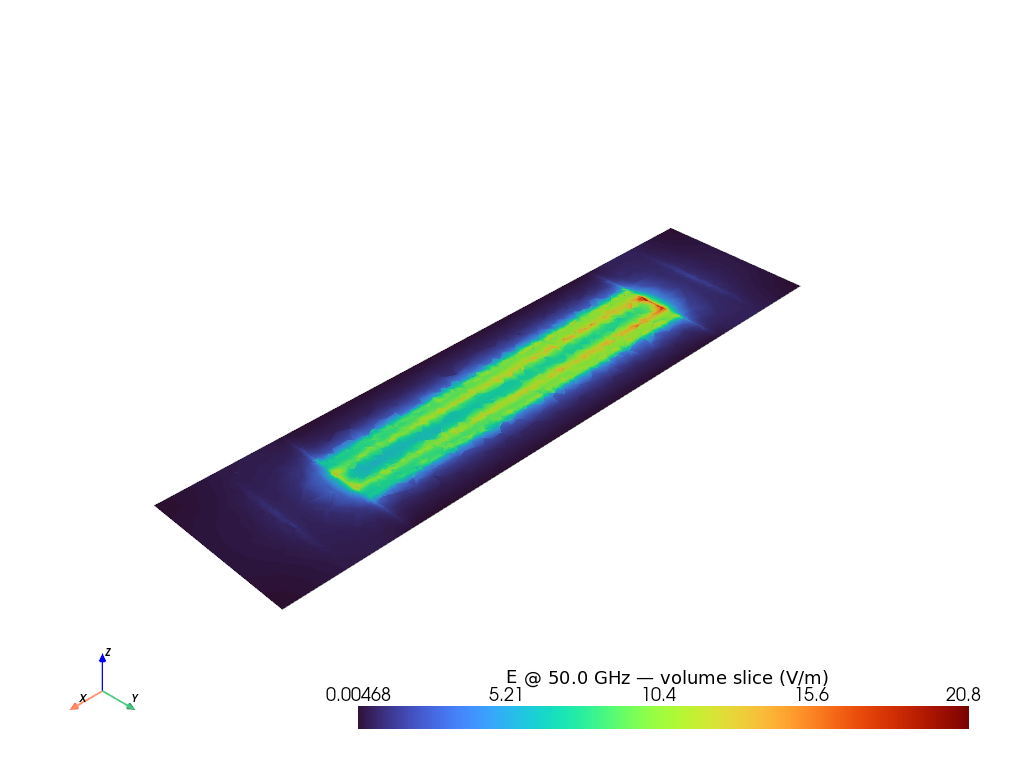

In [5]:
# |E| volume slice at z_conductor — uses extract_axis_slice + direct mesh rendering (no NaN)
vol_data = load_volume_field_data(results_dir, excitation=1)

pl_e = plot_volume_slice(
    vol_data,
    vector_field="E_real",
    component="mag",
    axis="z",
    value=z_conductor,
    cmap="turbo",
    scalar_bar_title=f"|E| @ {freq_ghz:.1f} GHz — volume slice (V/m)",
    off_screen=True,
)
pl_e.show(jupyter_backend="static")

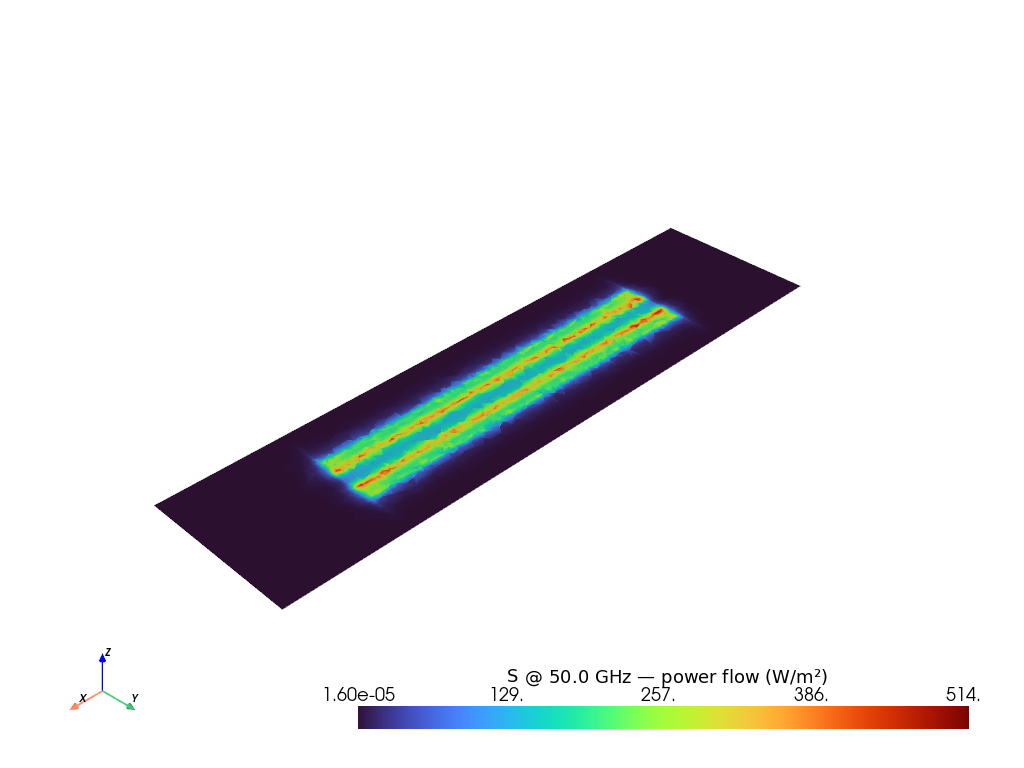

In [6]:
# |S| Poynting vector — power flow along the waveguide
pl_s_vol = plot_volume_slice(
    vol_data,
    vector_field="S",
    component="mag",
    axis="z",
    value=z_conductor,
    cmap="turbo",
    scalar_bar_title=f"|S| @ {freq_ghz:.1f} GHz — power flow (W/m²)",
    off_screen=True,
)
pl_s_vol.show(jupyter_backend="static")

### Surface-current boundary plot (NaN-free direct mesh rendering)

This uses :func:`gsim.palace.fields.plot_boundary_field` which renders the
actual boundary mesh cells directly — **no resampling to a regular grid** —
so there are **zero NaN values**.

In [7]:
# Load boundary field data — only topmetal2_xy conductor faces
bnd_data = load_boundary_field_data(
    results_dir,
    ctx,
    attributes=topmetal2_attrs,
    excitation=1,
)

print(f"Boundary mesh: {bnd_data.mesh.n_points:,} points, {bnd_data.mesh.n_cells:,} cells")
print(f"Available fields: {sorted(bnd_data.point_arrays)}")

# Explicit NaN check — the whole point
if "J_s_real" in bnd_data.point_arrays:
    from gsim.palace.fields import activate_vector_component
    scalar_name = activate_vector_component(bnd_data.mesh, "J_s_real", component="mag")
    n_nan = int(np.isnan(bnd_data.mesh.point_data[scalar_name]).sum())
    print(f"  NaN count in |J_s_real|: {n_nan} / {bnd_data.mesh.n_points:,} points")
    assert n_nan == 0, f"Expected 0 NaN values, got {n_nan}"

Boundary mesh: 100,944 points, 16,824 cells
Available fields: ['B_imag', 'B_real', 'E_imag', 'E_real', 'J_s_imag', 'J_s_real', 'Q_s_imag', 'Q_s_real', 'S', 'U_e', 'U_m', 'vtkOriginalPointIds']
  NaN count in |J_s_real|: 0 / 100,944 points


2026-07-08 17:05:54.258 ( 176.538s) [    760869D87080]        vtkRenderer.cxx:1144  WARN| vtkOpenGLRenderer (0x439bc070): Resetting view-up since view plane normal is parallel


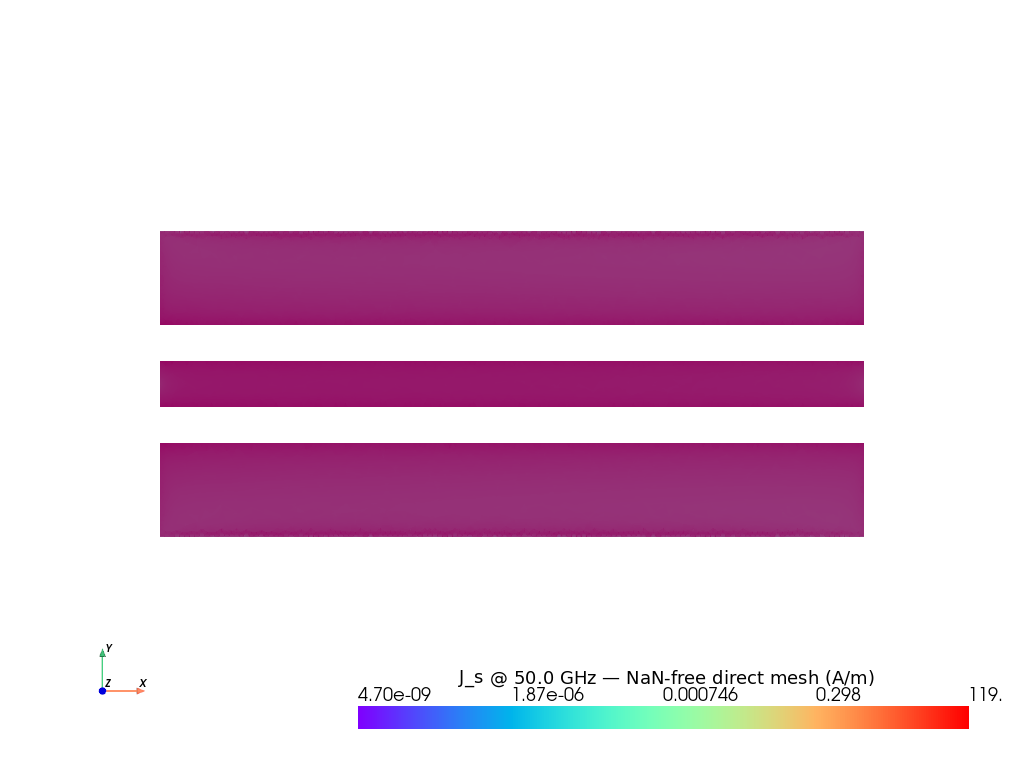

In [ ]:
# Plot surface current — NO NaN, direct mesh rendering
pl = plot_boundary_field(
    bnd_data,
    vector_field="J_s_real",
    component="mag",
    cmap="rainbow",
    log_scale=False,
    opacity=0.95,
    scalar_bar_title=f"|J_s| @ {freq_ghz:.1f} GHz — NaN-free direct mesh (A/m)",
    show_edges=False,
    off_screen=True,
)

# Orthographic top view
bounds = bnd_data.mesh.bounds
cx = 0.5 * (bounds[0] + bounds[1])
cy = 0.5 * (bounds[2] + bounds[3])
cz = 0.5 * (bounds[4] + bounds[5])
span_xy = max(bounds[1] - bounds[0], bounds[3] - bounds[2])
pl.camera_position = (cx, cy, cz + span_xy * 3.0)
pl.camera.focal_point = (cx, cy, cz)
pl.camera.up = (0.0, 1.0, 0.0)
pl.enable_parallel_projection()

pl.show(jupyter_backend="static")

### Cross-sections — YZ plane at x=0

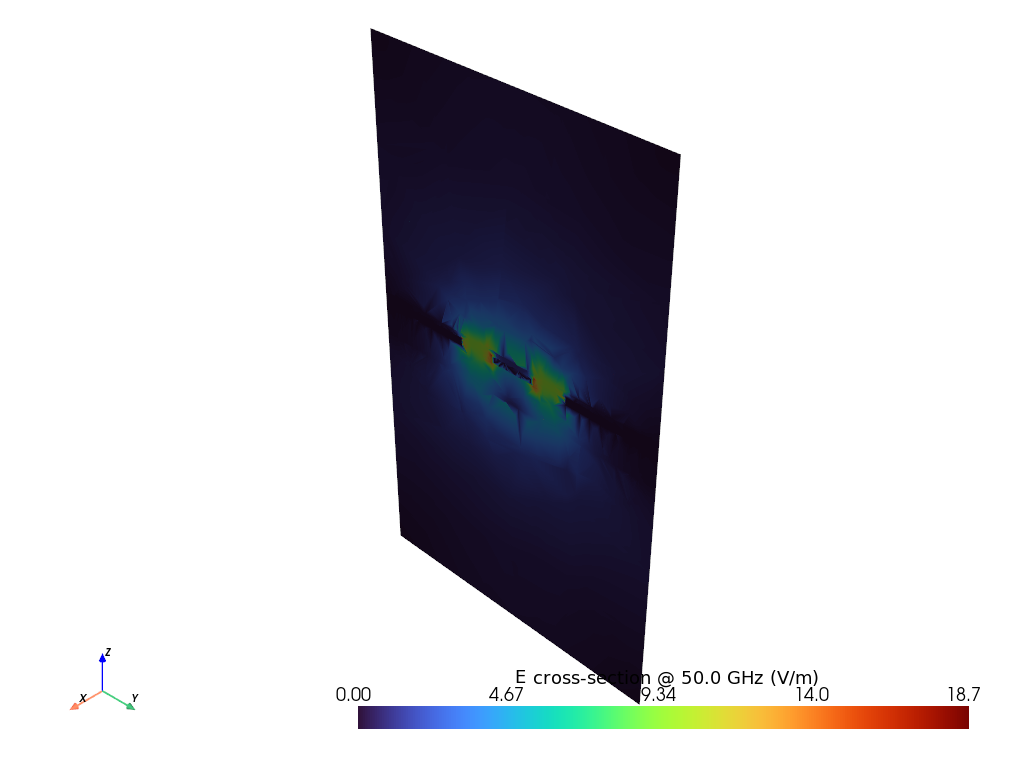

In [9]:
# |E| cross-section — uses 3D volume slice + direct mesh rendering
pl_cs_e = plot_volume_slice(
    vol_data,
    vector_field="E_real",
    component="mag",
    axis="x",
    value=0.0,
    cmap="turbo",
    scalar_bar_title=f"|E| cross-section @ {freq_ghz:.1f} GHz (V/m)",
    off_screen=True,
)

# Camera looks straight into the YZ plane (down the +X axis toward x=0)
_b = pl_cs_e.mesh.bounds
_cx, _cy, _cz = 0.0, 0.5 * (_b[2] + _b[3]), 0.5 * (_b[4] + _b[5])
_span_yz = max(_b[3] - _b[2], _b[5] - _b[4])
pl_cs_e.camera.position = (_cx + _span_yz * 3.0, _cy, _cz)
pl_cs_e.camera.focal_point = (_cx, _cy, _cz)
pl_cs_e.camera.up = (0.0, 0.0, 1.0)
pl_cs_e.enable_parallel_projection()

pl_cs_e.show(jupyter_backend="static")

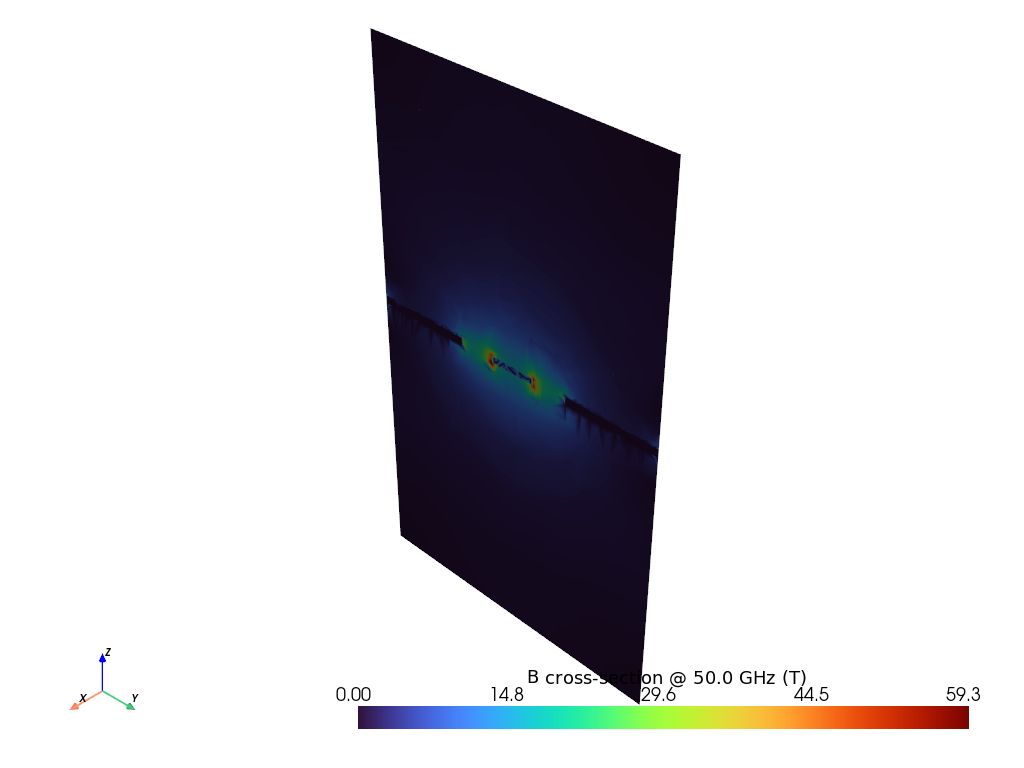

In [10]:
# |B| cross-section — magnetic field circulating around conductor
pl_cs_b = plot_volume_slice(
    vol_data,
    vector_field="B_real",
    component="mag",
    axis="x",
    value=0.0,
    cmap="turbo",
    scalar_bar_title=f"|B| cross-section @ {freq_ghz:.1f} GHz (T)",
    off_screen=True,
)

# Camera looks straight into the YZ plane (down the +X axis toward x=0)
_b = pl_cs_b.mesh.bounds
_cx, _cy, _cz = 0.0, 0.5 * (_b[2] + _b[3]), 0.5 * (_b[4] + _b[5])
_span_yz = max(_b[3] - _b[2], _b[5] - _b[4])
pl_cs_b.camera.position = (_cx + _span_yz * 3.0, _cy, _cz)
pl_cs_b.camera.focal_point = (_cx, _cy, _cz)
pl_cs_b.camera.up = (0.0, 0.0, 1.0)
pl_cs_b.enable_parallel_projection()

pl_cs_b.show(jupyter_backend="static")

### Field components — E_y at conductor layer

`E_y` is the dominant E-field component in a CPW — the transverse field across
the gaps between signal and ground. A diverging colormap shows the polarity
flipping between the two gaps.

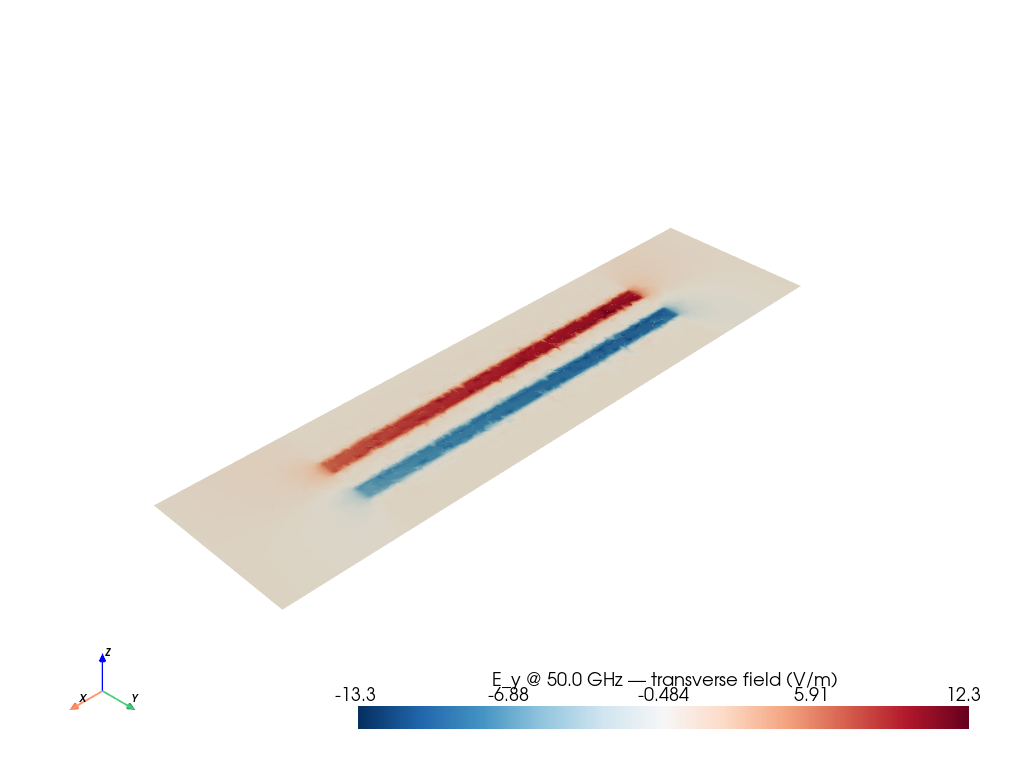

In [11]:
# E_y component via plot_volume_slice with vector component 'y'
pl_ey = plot_volume_slice(
    vol_data,
    vector_field="E_real",
    component="y",
    axis="z",
    value=z_conductor,
    cmap="RdBu_r",
    scalar_bar_title=f"E_y @ {freq_ghz:.1f} GHz — transverse field (V/m)",
    off_screen=True,
)
pl_ey.show(jupyter_backend="static")